In [1]:
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

In [2]:
import geoflowkit as gfk
from geoflowkit import DBSCANFlow
from geoflowkit import KMedoidFlow

In [3]:
plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['mathtext.fontset'] = 'stix'

In [4]:
fdf = gfk.read_file('./data/sys_flow/sys_flow_dataset1.gpkg', layer='CP')
fdf = fdf.to_crs('epsg:4526')
fdf.head()

,ox,oy,dx,dy,angle,length,flow_type,geometry
0,1.001293,0.357219,0.200445,0.859033,2.581842,0.945079,cluster1,"FLOW (28295577.45928605 19900871.566128597, 28..."
1,0.950528,0.401534,0.143220,0.861170,2.624019,0.928985,cluster1,"FLOW (28310509.790896393 19888341.52555409, 28..."
2,0.953673,0.382611,0.143493,0.829467,2.637559,0.925241,cluster1,"FLOW (28309507.53568825 19893772.92150171, 285..."
3,0.971746,0.389120,0.142001,0.848156,2.636277,0.948256,cluster1,"FLOW (28304298.91639196 19891812.159775548, 28..."
4,0.968248,0.377644,0.173622,0.842101,2.612650,0.920409,cluster1,"FLOW (28305259.03233836 19895134.768345945, 28..."


# K-Meriods Clustering

In [5]:
model = KMedoidFlow(
    n_clusters=5, distance='max'
)
model = model.fit(fdf)

In [6]:
model.cluster_centers_

array([ 26, 146,   0, 103,  89])

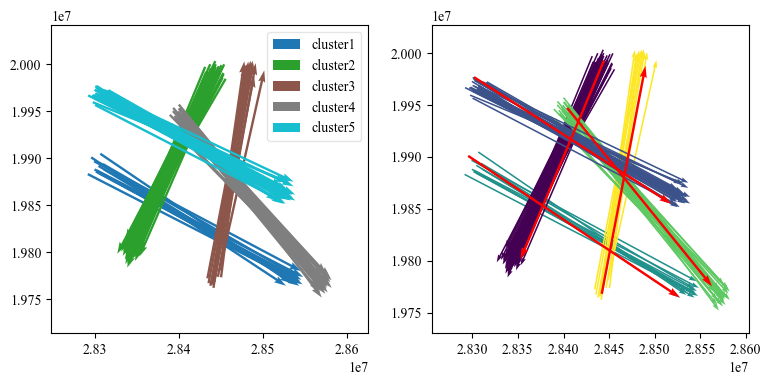

In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 4))

fdf['label'] = model.labels_
fdf.plot(ax=ax1, column='flow_type', zoom=0.15)
fdf.plot(ax=ax2, column='label', zoom=0.15)

fdf.loc[model.cluster_centers_, :].plot(ax=ax2, color='red', zoom=0.15);

# DBSCAN Clustering

In [22]:
model = DBSCANFlow(
    eps=0.5e5, min_samples=5, distance='max'
)
model = model.fit(fdf)

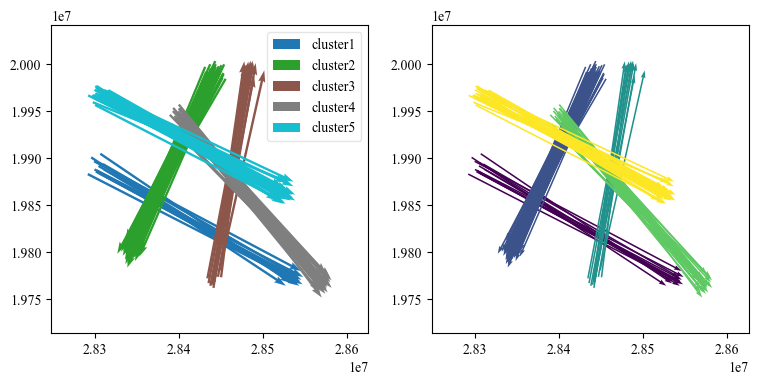

In [24]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 4))

fdf['label'] = model.labels_
fdf.plot(ax=ax1, column='flow_type', zoom=0.15)
fdf.plot(ax=ax2, column='label', zoom=0.15);